# **Project on Manufacturing Data recorded daily for 12 months**

**A. Import main modules**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
os.makedirs("outputs", exist_ok=True)

**B. Extract and explore files for analysis**

In [3]:
DF = pd.read_csv("manufacturing_quality_data.csv")

In [4]:
DF.head()
DF.info()
DF.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   batch_id         4899 non-null   object 
 1   production_date  5000 non-null   object 
 2   temperature      4820 non-null   float64
 3   pressure         5000 non-null   float64
 4   pressure_unit    5000 non-null   object 
 5   machine_id       5000 non-null   object 
 6   defect_count     5000 non-null   int64  
 7   operator_id      5000 non-null   object 
 8   quality_score    5000 non-null   float64
 9   humidity         5000 non-null   float64
 10  machine_runtime  5000 non-null   int64  
dtypes: float64(4), int64(2), object(5)
memory usage: 429.8+ KB


,temperature,pressure,defect_count,quality_score,humidity,machine_runtime
count,4820.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,235.113405,43.742130,23.839200,80.823008,54.732640,37.755600
std,251.725720,47.156553,16.664756,27.768449,14.460624,20.024696
min,150.000663,1.000000,-50.000000,0.000000,30.000000,4.000000
25%,176.035238,5.597500,11.000000,83.000000,42.000000,20.000000
50%,201.361158,15.405000,24.000000,89.000000,54.600000,38.000000
75%,227.131258,80.602500,38.000000,95.000000,67.400000,55.000000
max,2490.962229,149.930000,50.000000,100.000000,80.000000,72.000000


In [5]:
DFs = DF.duplicated().any()
DFs

False

**C. Clean Data**

In [6]:
#Convert Date to datetime format
DF['production_date'] = pd.to_datetime(DF['production_date'])

In [7]:
# standardize pressure units and create new pressure standardized column(pressure_bar)
CF_psi_to_bar = 0.0689476

def convert_to_bar(row):
    if row['pressure_unit'].lower() == 'psi':
        return row['pressure'] * CF_psi_to_bar
    elif row['pressure_unit'].lower() == 'bar':
        return row['pressure']
    else:
        return np.nan

DF['pressure_bar'] = DF.apply(convert_to_bar, axis=1)

In [8]:
# drop redundant pressure and pressure unit columns
DF1 =DF.drop(['pressure','pressure_unit'], axis =1)

In [9]:
#standardize quality score(convert all to percentages)
DF1['quality_score'] = np.where(DF1['quality_score'] <= 1, DF1['quality_score'] * 100 ,
DF1['quality_score'])

In [10]:
# standardize defect_count to remove negative values
DF1['defect_count'] = np.where(DF1['defect_count'] < 0, DF1['defect_count'] == 0, DF1['defect_count']) 

In [11]:
#drop null values since null rows < 5% of total # of rows 
DF1 = DF1.dropna()

In [12]:
#extract numerical IDs from operator and machine columns to create standard ID columns,then delete extra columns
DF1['Operator_ID'] = DF1['operator_id'].str.extract(r'(\d+)')
DF1['Machine_ID'] = DF1['machine_id'].str.extract(r'(\d+)')
DF1 = DF1.drop(columns = ['machine_id','operator_id'], axis =1)

**D. Exploratory Analysis**

In [13]:
#correlation analysis of numerated columns
DF1[['defect_count','quality_score','humidity','machine_runtime','pressure_bar','temperature']].corr()

,defect_count,quality_score,humidity,machine_runtime,pressure_bar,temperature
defect_count,1.000000,-0.002333,0.002183,0.001161,0.024353,-0.003638
quality_score,-0.002333,1.000000,0.008527,0.013375,-0.001653,-0.016411
humidity,0.002183,0.008527,1.000000,-0.002942,-0.009636,0.005597
machine_runtime,0.001161,0.013375,-0.002942,1.000000,-0.016455,0.000795
pressure_bar,0.024353,-0.001653,-0.009636,-0.016455,1.000000,-0.001532
temperature,-0.003638,-0.016411,0.005597,0.000795,-0.001532,1.000000


In [14]:
#create monthly dataframe with summed defect counts per month for the whole period 
Monthly = DF1[['production_date','defect_count','machine_runtime']].groupby(pd.Grouper(key='production_date',freq='MS')).sum()

In [15]:
# calculate monthly defect rates
Monthly['D_rate'] = Monthly['defect_count']/Monthly['machine_runtime']

In [16]:
#reset index
Monthly= Monthly.reset_index()

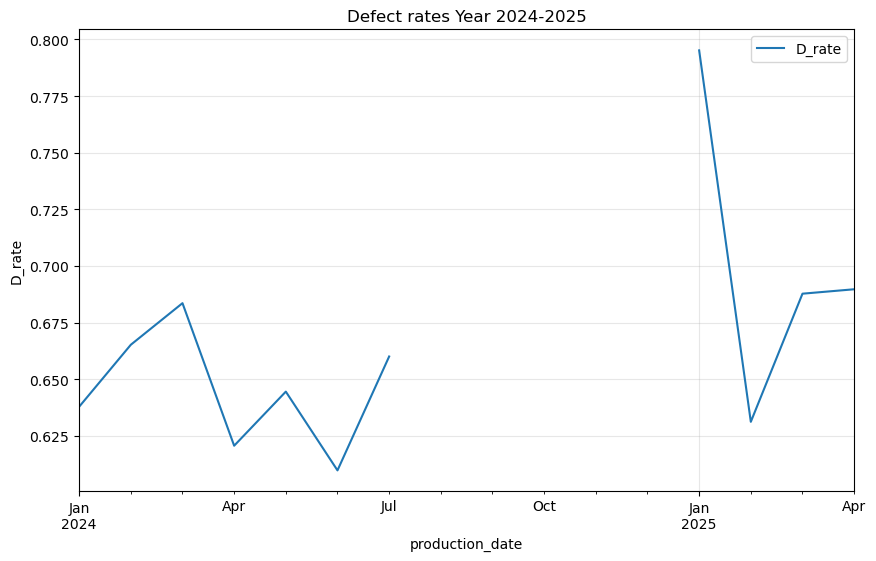

In [17]:
#create line chart visualisation for monthly defect rates

Monthly.plot(x='production_date', y='D_rate', kind='line', figsize= (10, 6))
plt.title('Defect rates Year 2024-2025')
plt.xlabel('production_date')
plt.ylabel('D_rate')
plt.grid(True, alpha=0.3)
plt.savefig("outputs/Defect_rates.png", bbox_inches = "tight", dpi=300)
plt.show()

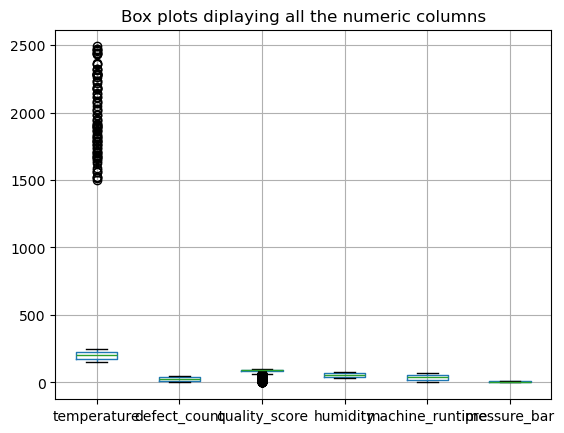

In [18]:
#box plots of all operational variables
DF1.boxplot()
plt.title('Box plots diplaying all the numeric columns')
plt.savefig("outputs/Box_plots.png", bbox_inches="tight", dpi=300)
plt.show()

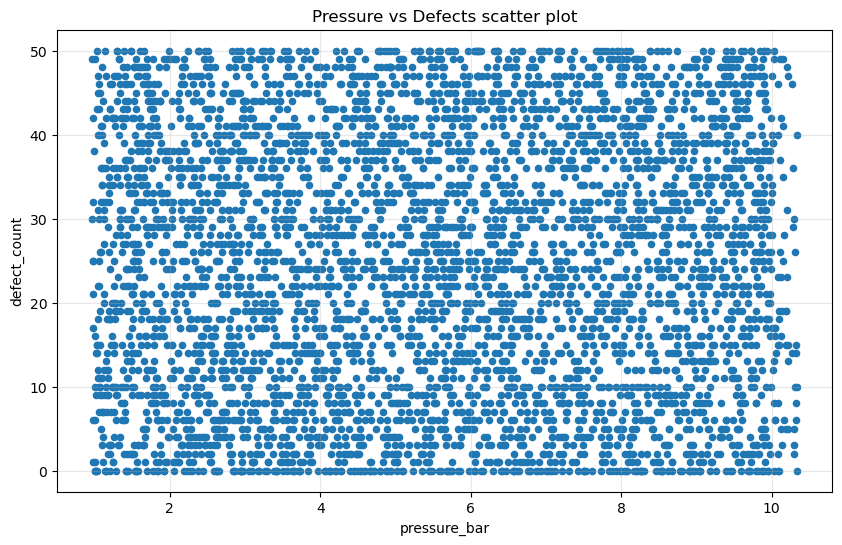

In [19]:
#create scatter plot to investigate pressure/defects correlation

DF1.plot(x='pressure_bar', y='defect_count', kind='scatter', figsize= (10, 6))
plt.title('Pressure vs Defects scatter plot')
plt.xlabel('pressure_bar')
plt.ylabel('defect_count')
plt.grid(True, alpha=0.3)
plt.savefig("outputs/Pressure_Defects.png", bbox_inches = "tight", dpi=300)
plt.show()

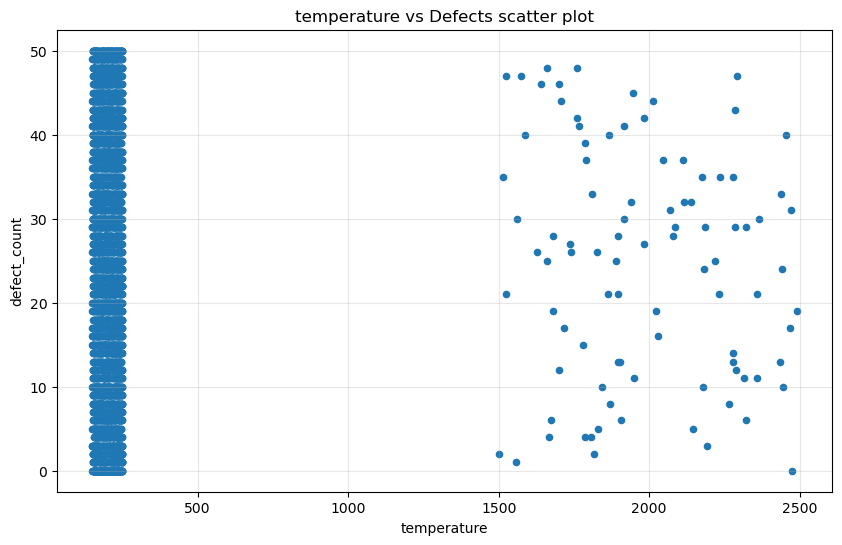

In [20]:
#create scatter graph to investigate temperature/defects correlation

DF1.plot(x='temperature', y='defect_count', kind='scatter', figsize= (10, 6))
plt.title('temperature vs Defects scatter plot')
plt.xlabel('temperature')
plt.ylabel('defect_count')
plt.grid(True, alpha=0.3)
plt.savefig("outputs/temperature_Defects.png", bbox_inches = "tight", dpi=300)
plt.show()

In [21]:
# select and store dataframe where temperatures are outliers
DF1_TQ = DF1[DF1['temperature'] > 500]

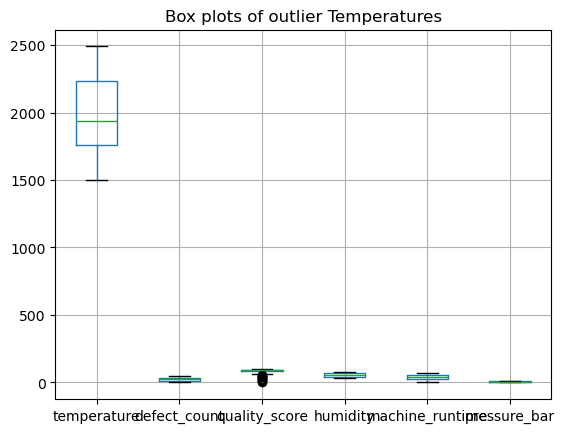

In [22]:
DF1_TQ.boxplot()
plt.title('Box plots of outlier Temperatures')
plt.show()

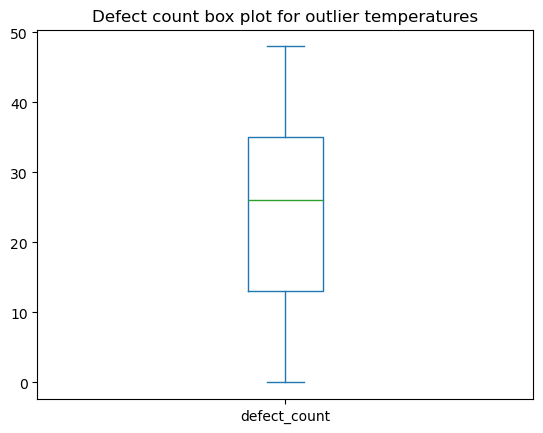

In [23]:
DF1_TQ['defect_count'].plot(kind='box', title='Defect count box plot for outlier temperatures')
plt.show()

In [24]:
# determine defect counts per operator
operator = DF1[['Operator_ID','defect_count']].groupby('Operator_ID').sum('defect_count')

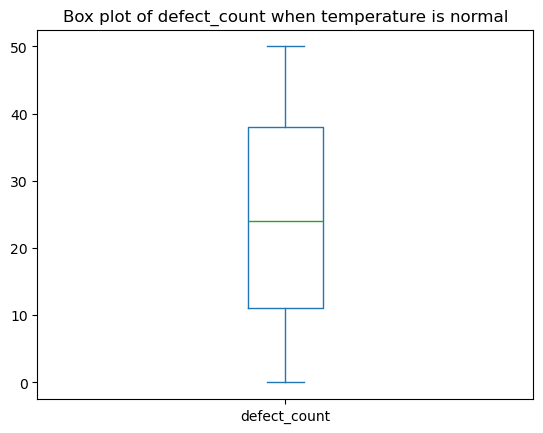

In [25]:
DF1_Q = DF1[DF1['temperature'] <500]
DF1_Q['defect_count'].plot(kind='box', title='Box plot of defect_count when temperature is normal')
plt.show()

In [26]:
#determine total defects per operator for the duration
op_defect = DF1[['Operator_ID','defect_count']].groupby('Operator_ID').sum('defect_count')

In [27]:
op_defect = op_defect.reset_index()

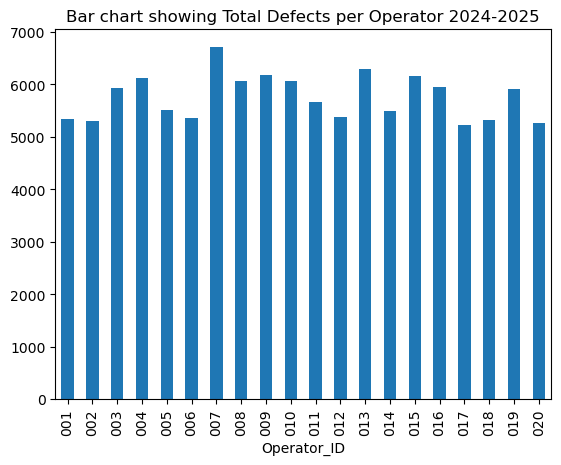

In [28]:
# plot bar graph showing operator defects for the duration
op_defect.plot(kind='bar', x='Operator_ID', y='defect_count', title ='Bar chart showing Total Defects per Operator 2024-2025', legend= False)
plt.savefig("outputs/Operator_Defects.png", bbox_inches="tight", dpi=300)
plt.show()

In [29]:
#determine operator mean quality score for the duration
OP_Quality_S = DF1[['Operator_ID','quality_score']].groupby('Operator_ID').mean('quality_score')

In [30]:
#reset index before plotting
OP_Quality_S = OP_Quality_S.reset_index()

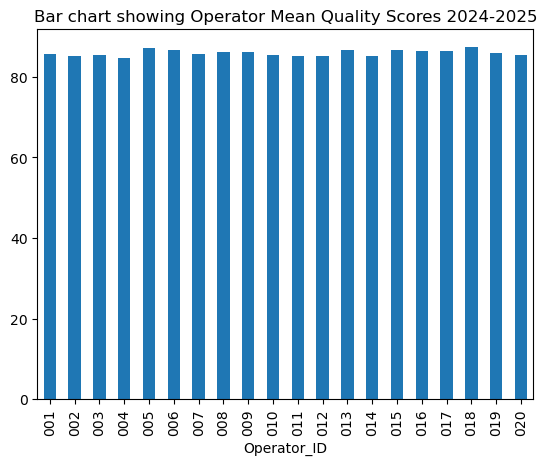

In [31]:
#plot bar graph of mean score per operator for the duration
OP_Quality_S.plot(kind='bar', x= 'Operator_ID', y = 'quality_score', title= 'Bar chart showing Operator Mean Quality Scores 2024-2025', legend= False)
plt.savefig("outputs/Operator_MeanScores.png", bbox_inches="tight", dpi=300)
plt.show()

In [32]:
#create new dataframe to determine machine defect rate
M_Drate = DF1[['Machine_ID','defect_count','machine_runtime']]

In [33]:
#calculate defect rate into a new column
M_Drate['D_rate'] = M_Drate['defect_count'] / M_Drate['machine_runtime']

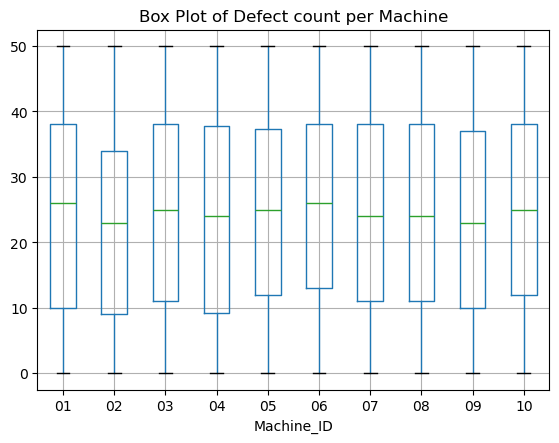

In [34]:
# Plot defect count per machine

M_Drate.boxplot(column='defect_count', by='Machine_ID')
plt.title('Box Plot of Defect count per Machine')
plt.suptitle("") # Suppress the default pandas title
plt.savefig("outputs/BoxPlots_DefectCounts.png", bbox_inches="tight", dpi=300)
plt.show()

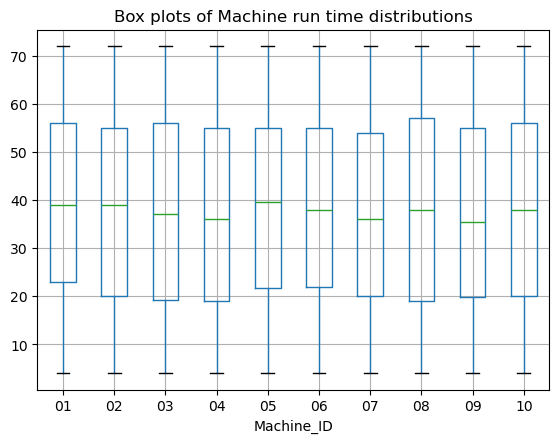

In [35]:
# Plot of machine runtime per machine

M_Drate.boxplot(column='machine_runtime', by='Machine_ID')
plt.title('Box plots of Machine run time distributions')
plt.suptitle("") # Suppress the default pandas title
plt.show()

In [36]:
#calculate machine defect rate 
Def_Rate = M_Drate[['Machine_ID','D_rate']].groupby('Machine_ID').mean('D_rate')

In [37]:
#print dataframe
Def_Rate

,D_rate
Machine_ID,
01,1.122380
02,0.976553
03,1.182370
04,1.069756
05,1.071068
06,1.123404
07,1.077477
08,1.064379
09,1.125171


In [38]:
#reset index before plotting 
Def_Rate = Def_Rate.reset_index()

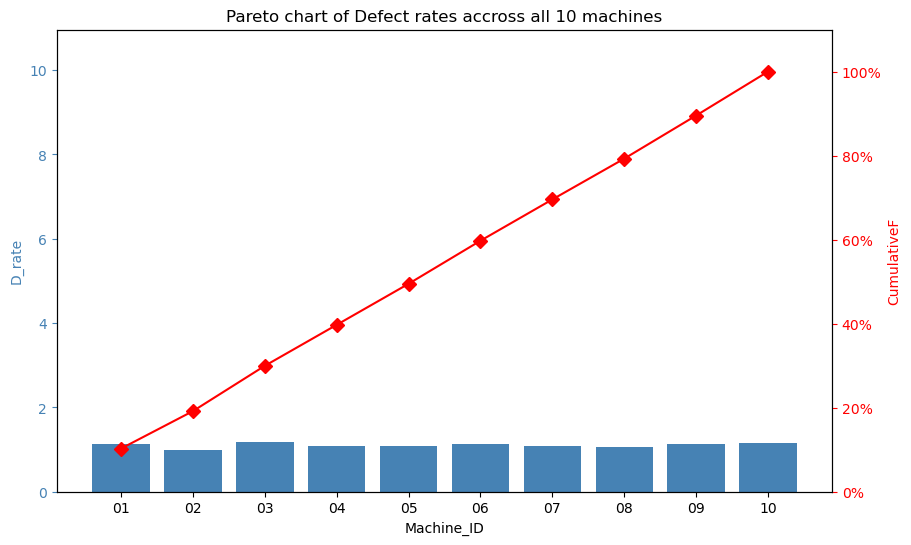

In [39]:
# create pareto chart to show machne defects over time,pareto chart helps one apply the 80/20 rule and find the elephant in the room
from matplotlib.ticker import PercentFormatter
Def_Rate.sort_values(by='D_rate',ascending=False)
Def_Rate['CumulativeF'] = Def_Rate['D_rate'].cumsum()/Def_Rate['D_rate'].sum() *100
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(Def_Rate['Machine_ID'], Def_Rate['D_rate'], color ='steelblue')
ax1.set_xlabel('Machine_ID')
ax1.set_ylabel('D_rate',color='steelblue')
ax1.tick_params(axis='y', colors = 'steelblue')
ax1.set_ylim([0, Def_Rate['D_rate'].sum()])

ax2 = ax1.twinx()
ax2.plot(Def_Rate['Machine_ID'], Def_Rate['CumulativeF'], color = 'red', marker = 'D', ms=7, linestyle='-')
ax2.set_ylabel('CumulativeF',color='red')
ax2.tick_params(axis='y',colors='red')
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.set_ylim([0, 110])
plt.title('Pareto chart of Defect rates accross all 10 machines')
plt.savefig("outputs/MachineDefectRates_Pareto.png", bbox_inches="tight",dpi=300)
plt.show()

In [40]:
#create a dataframe that displays the mean machine runtime per machine for the duration
Mac_Ov_RT = M_Drate[['Machine_ID','machine_runtime']].groupby('Machine_ID').mean('machine_runtime')

In [41]:
#reset index for plotting
Mac_Ov_RT = Mac_Ov_RT.reset_index()

In [42]:
# dataframe of mean machine runtime for all the machines
Mac_Ov_RT

,Machine_ID,machine_runtime
0,01,38.756048
1,02,38.082430
2,03,37.504149
3,04,37.015152
4,05,38.475877
5,06,38.320879
6,07,37.066239
7,08,37.966942
8,09,36.481092
9,10,37.865702


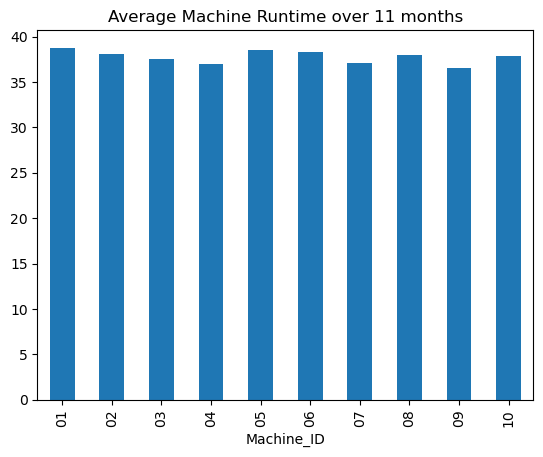

In [43]:
# bar graph for mean machine runtime for all ten machines for the duration
Mac_Ov_RT.plot(kind='bar', x='Machine_ID', y='machine_runtime', title ='Average Machine Runtime over 11 months',legend= False)
plt.savefig("outputs/AverageMachine_RunTime.png", bbox_inches="tight", dpi=300)
plt.show()

In [44]:
# standardise columns for final dataset
DF1.rename(columns=str.upper, inplace=True)

In [45]:
# print clean dataset
DF1.head()

,BATCH_ID,PRODUCTION_DATE,TEMPERATURE,DEFECT_COUNT,QUALITY_SCORE,HUMIDITY,MACHINE_RUNTIME,PRESSURE_BAR,OPERATOR_ID,MACHINE_ID
0,BATCH_4616,2024-06-15,242.055745,42,88.0,79.9,55,2.500000,014,03
1,BATCH_7165,2024-02-11,205.454683,6,45.0,52.2,49,5.640000,016,01
2,BATCH_2802,2024-06-23,164.441288,33,100.0,79.5,18,2.393861,007,07
3,BATCH_6856,2024-02-28,182.478732,23,82.0,54.8,68,8.711529,002,03
4,BATCH_8953,2024-06-21,204.735513,0,97.0,77.3,45,4.890000,007,06


In [46]:
# export final data set to file
DF1.to_csv('Manufacturing_Quality_Data(Clean).csv', index=False)

**Conclusion**
- All variables have  weak correlations with defect counts, all below 0.3
- Machine defect rates are very close,ranging from 0.97-1.18,indicating consistent perfomance
- Scatter plots show a random cloud,confirming no strong linear relationship
- The process appears stable:the defects arise likely from many minorfactors(common cause variation)
- Overall the process is balanced across machines and operational parameters